# INF8225 — Projet : Analyse comparative de l'architecture Whisper pour l'ASR en français
**École Polytechnique de Montréal — Équipe 12**  
Hamza El Haddad · Jules Gouy

---

## 🔄 Stratégie de reprise multi-sessions

Chaque étape terminée est sauvegardée comme **WandB Artifact** (résultats JSON + weights + figures).  
À chaque nouvelle session Colab, exécutez **§1 puis §0** — tout ce qui a déjà été calculé
sera récupéré automatiquement depuis WandB sans recalcul.

| Artifact WandB | Contenu sauvegardé |
|---|---|
| `baseline` | WER/CER par variante (JSON) |
| `scaling` | Courbe WER vs paramètres + latence (JSON + figures) |
| `finetuning` | Weights du modèle + métriques test + courbes |
| `ablation-lr` | WER val par taux d'apprentissage (JSON) |
| `ablation-freeze` | WER val gel vs libre (JSON) |
| `wav2vec` | WER/CER wav2vec 2.0 (JSON) |
| `figures` | Toutes les figures PNG |

## Table des matières
**[§1 Setup](#section1)** → **[§0 Reprise](#section0)** → §2 Datasets → §3 EDA → §4 Baseline → §5 Scaling & Latence → §6 Erreurs → §7 Fine-tuning → §8 Ablations → §9 wav2vec → §10 Synthèse


---
## 1. Setup & dépendances <a id='section1'></a>
> ▶️ **Toujours exécuter cette section en premier**, même lors d'une reprise.

In [1]:
import subprocess
r = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(r.stdout if r.returncode == 0 else "⚠️  Pas de GPU — Runtime > Change runtime type > T4 GPU")

Tue Apr 21 15:50:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%%capture
!pip install -q \
    transformers==4.40.0 datasets==2.19.0 evaluate==0.4.2 jiwer==3.0.4 \
    accelerate==0.29.3 librosa==0.10.1 soundfile==0.12.1 wandb==0.17.0 \
    audiomentations==0.36.2 sentencepiece bitsandbytes
print("OK")

In [3]:
!pip install evaluate
!pip install jiwer

In [4]:
import os, re, json, random, warnings, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Union
from pathlib import Path
from IPython.display import Audio, display

import torch
from transformers import (
    WhisperProcessor, WhisperForConditionalGeneration,
    WhisperTokenizer, WhisperFeatureExtractor,
    Seq2SeqTrainer, Seq2SeqTrainingArguments, EarlyStoppingCallback,
    Wav2Vec2ForCTC, Wav2Vec2Processor,
)
from datasets import load_dataset, Dataset, Audio as AudioFeature
import evaluate
from jiwer import wer, cer
import wandb

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {DEVICE}")
if DEVICE == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# ⚙️  CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════
WANDB_API_KEY  = "TOKEN"   # <-- remplacer
WANDB_PROJECT  = "inf8225-whisper-french"
WANDB_ENTITY   = None                  # votre username WandB (ou None = auto)
HF_TOKEN       = "TOKEN"        # <-- remplacer

# Répertoires
LOCAL_CKPT_DIR = "/content/drive/MyDrive/INF8225/checkpoints"
FIG_DIR        = "/content/figures"
os.makedirs(LOCAL_CKPT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# Paramètres dataset — MLS French (Multilingual LibriSpeech)
N_TEST      = 500    # exemples d'évaluation
N_TRAIN_FT  = 2000   # exemples de fine-tuning
N_VAL_FT    = 300    # exemples de validation
SAMPLE_RATE = 16_000
MODEL_FT    = "openai/whisper-small"

wandb.login(key=WANDB_API_KEY)
print("✅ Config OK")


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: elhaddad-hamza1003 (elhaddad-hamza1003-imt-atlantique) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ Config OK


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# 🗄️  UTILITAIRES DE CHECKPOINT
# ══════════════════════════════════════════════════════════════════════════════

def _art_name(step: str) -> str:
    return f"{WANDB_PROJECT}-{step}".replace("/", "-")

def artifact_exists(step: str) -> bool:
    """Retourne True si un artifact 'latest' existe déjà sur WandB pour cette étape."""
    try:
        api    = wandb.Api()
        entity = WANDB_ENTITY or api.default_entity
        api.artifact(f"{entity}/{WANDB_PROJECT}/{_art_name(step)}:latest")
        return True
    except Exception:
        return False

def save_artifact(step: str, artifact_type: str, files: Dict[str, str],
                  metadata: Optional[Dict] = None, run=None):
    """
    Sauvegarde des fichiers/dossiers comme WandB Artifact.
    files = {"nom_logique": "/chemin/local"}
    Si run=None, un run temporaire est créé et fermé automatiquement.
    """
    owns_run = run is None
    if owns_run:
        run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY,
                         name=f"ckpt-{step}", job_type="checkpoint", reinit="finish_previous")
    art = wandb.Artifact(name=_art_name(step), type=artifact_type,
                         metadata=metadata or {})
    for logical, local in files.items():
        p = Path(local)
        if p.is_dir():   art.add_dir(str(p), name=logical)
        elif p.is_file(): art.add_file(str(p), name=logical)
        else: print(f"  ⚠️  Introuvable : {local}")
    run.log_artifact(art)
    art.wait()
    print(f"  💾 Artifact '{_art_name(step)}' sauvegardé sur WandB")
    if owns_run:
        wandb.finish()

def load_artifact(step: str, dest: str) -> str:
    """Télécharge un artifact WandB et retourne le chemin local."""
    api    = wandb.Api()
    entity = WANDB_ENTITY or api.default_entity
    art    = api.artifact(f"{entity}/{WANDB_PROJECT}/{_art_name(step)}:latest")
    path   = art.download(root=dest)
    print(f"  📥 '{_art_name(step)}' → {path}")
    return path

def save_json(data, path):
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def save_fig(name: str) -> str:
    path = f"{FIG_DIR}/{name}"
    plt.savefig(path, bbox_inches='tight')
    return path

# Aperçu du statut actuel
print("\n── Statut des étapes sur WandB ──")
STEPS = ["baseline","finetuning","ablation-lr","ablation-freeze","ablation-augment","wav2vec"]
for s in STEPS:
    icon = "✅" if artifact_exists(s) else "⬜"
    print(f"  {icon}  {s}")


── Statut des étapes sur WandB ──
  ✅  baseline
  ✅  finetuning
  ✅  ablation-lr
  ✅  ablation-freeze
  ⬜  ablation-augment
  ⬜  wav2vec


---
## 0. 🔄 Reprise de session <a id='section0'></a>

**Exécutez cette cellule après §1 à chaque redémarrage.**  
Elle récupère automatiquement tous les résultats déjà calculés depuis WandB  
et affiche les sections qu'il reste à exécuter.

In [7]:
RESUME_DIR = "/content/resumed"
os.makedirs(RESUME_DIR, exist_ok=True)

# ── État global (None = pas encore calculé) ───────────────────────────────────
baseline_results        = None
ft_result               = None
FT_MODEL_PATH           = None
ablation_lr_results     = None
ablation_freeze_results = None
ablation_aug_wer        = None
w2v_fr                  = None
w2v_frca                = None

print("═" * 55)
print("       RÉCUPÉRATION DES CHECKPOINTS WANDB")
print("═" * 55)

# ── §4 Baseline ──────────────────────────────────────────────────────────────
if artifact_exists("baseline"):
    p = load_artifact("baseline", f"{RESUME_DIR}/baseline")
    baseline_results = load_json(f"{p}/baseline_results.json")
    print(f"  → {len(baseline_results)} combinaisons (variante × dataset)")
else:
    print("  ⬜ baseline — à calculer en §4")

# ── §6 Fine-tuning ────────────────────────────────────────────────────────────
if artifact_exists("finetuning"):
    p = load_artifact("finetuning", f"{RESUME_DIR}/finetuning")
    ft_result     = load_json(f"{p}/ft_result.json")
    FT_MODEL_PATH = f"{p}/model"
    print(f"  → WER test = {ft_result['wer']*100:.2f}%  |  Modèle : {FT_MODEL_PATH}")
else:
    print("  ⬜ finetuning — à calculer en §6")

# ── §7 Ablation LR ───────────────────────────────────────────────────────────
if artifact_exists("ablation-lr"):
    p = load_artifact("ablation-lr", f"{RESUME_DIR}/ablation-lr")
    # Clés JSON = strings → reconvertir en float
    ablation_lr_results = {float(k): v
                           for k, v in load_json(f"{p}/ablation_lr.json").items()}
    print(f"  → ablation LR : {ablation_lr_results}")
else:
    print("  ⬜ ablation-lr — à calculer en §7")

# ── §7 Ablation freeze ───────────────────────────────────────────────────────
if artifact_exists("ablation-freeze"):
    p = load_artifact("ablation-freeze", f"{RESUME_DIR}/ablation-freeze")
    ablation_freeze_results = load_json(f"{p}/ablation_freeze.json")
    print(f"  → ablation freeze : {ablation_freeze_results}")
else:
    print("  ⬜ ablation-freeze — à calculer en §7")

# ── §7 Ablation augmentation ─────────────────────────────────────────────────
if artifact_exists("ablation-augment"):
    p = load_artifact("ablation-augment", f"{RESUME_DIR}/ablation-augment")
    ablation_aug_wer = load_json(f"{p}/ablation_augment.json")["wer"]
    print(f"  → ablation augmentation : WER={ablation_aug_wer:.2f}%")
else:
    print("  ⬜ ablation-augment — à calculer en §7")

# ── §8 wav2vec 2.0 ───────────────────────────────────────────────────────────
if artifact_exists("wav2vec"):
    p    = load_artifact("wav2vec", f"{RESUME_DIR}/wav2vec")
    data = load_json(f"{p}/wav2vec_results.json")
    w2v_fr   = data["fr"]
    w2v_frca = data["fr-CA"]
    print(f"  → wav2vec fr={w2v_fr['wer']*100:.2f}%  fr-CA={w2v_frca['wer']*100:.2f}%")
else:
    print("  ⬜ wav2vec — à calculer en §8")

print()
todo = [s for s in STEPS if not artifact_exists(s)]
if todo:
    print(f"📋 Sections restantes : {', '.join(todo)}")
else:
    print("🎉 Toutes les étapes sont complètes — passez directement à §9 (Synthèse)")

═══════════════════════════════════════════════════════
       RÉCUPÉRATION DES CHECKPOINTS WANDB
═══════════════════════════════════════════════════════


wandb:   1 of 1 files downloaded.  


  📥 'inf8225-whisper-french-baseline' → /content/resumed/baseline
  → 6 combinaisons (variante × dataset)


wandb: Downloading large artifact 'inf8225-whisper-french-finetuning:latest', 9226.74MB. 36 files...
wandb:   36 of 36 files downloaded.  
Done. 00:00:00.8 (11736.3MB/s)


  📥 'inf8225-whisper-french-finetuning' → /content/resumed/finetuning
  → WER test = 13.41%  |  Modèle : /content/resumed/finetuning/model


wandb:   1 of 1 files downloaded.  


  📥 'inf8225-whisper-french-ablation-lr' → /content/resumed/ablation-lr
  → ablation LR : {1e-05: 12.576020851433537, 3e-05: 13.140747176368375, 5e-05: 13.705473501303214}


wandb:   1 of 1 files downloaded.  


  📥 'inf8225-whisper-french-ablation-freeze' → /content/resumed/ablation-freeze
  → ablation freeze : {'encodeur_libre': 12.576020851433537, 'encodeur_gelé': 13.495511149724877}
  ⬜ ablation-augment — à calculer en §7
  ⬜ wav2vec — à calculer en §8

📋 Sections restantes : ablation-augment, wav2vec


---
## 2. Chargement des datasets <a id='section2'></a>

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Dataset : facebook/multilingual_librispeech "french"
#   → Parquet natif, aucune authentification requise
#   → Corpus de français lu (livres audio), contrôlé et homogène
#   → Splits utilisés :
#       • test  (500 ex.)  → évaluation baseline & comparaison
#       • train (2000 ex.) → fine-tuning Whisper small
#       • dev   (300 ex.)  → validation pendant le fine-tuning
# ══════════════════════════════════════════════════════════════════════════════

def stream_mls(split, n, offset=0):
    """
    Charge n exemples de MLS french depuis le split donné.
    Retourne un Dataset HF avec colonnes 'sentence' et 'audio' (16kHz).
    """
    ds_stream = load_dataset(
        "facebook/multilingual_librispeech", "french",
        split=split, streaming=True,
    )
    samples = []
    for i, ex in enumerate(ds_stream):
        if i < offset:
            continue
        samples.append({
            "sentence": ex["transcript"],
            "audio":    ex["audio"],
        })
        if len(samples) >= n:
            break
        if len(samples) % 100 == 0:
            print(f"  {len(samples)}/{n} …")
    return Dataset.from_list(samples).cast_column(
        "audio", AudioFeature(sampling_rate=SAMPLE_RATE)
    )

print("Chargement MLS french → test (évaluation) …")
mls_test  = stream_mls("test",  N_TEST)

print("\nChargement MLS french → train (fine-tuning) …")
mls_train = stream_mls("train", N_TRAIN_FT)

print("\nChargement MLS french → dev (validation) …")
mls_val   = stream_mls("dev",   N_VAL_FT)

# Alias compatibles avec le reste du notebook
cv_fr   = {"test": mls_test}
cv_frca = {"test": mls_test, "train": mls_train, "validation": mls_val}

print(f"\n✅ test  : {len(mls_test)}  ex. (MLS french / test)")
print(f"✅ train : {len(mls_train)} ex. (MLS french / train)")
print(f"✅ val   : {len(mls_val)}  ex. (MLS french / dev)")
print(f"Colonnes : {mls_test.column_names}")


Chargement MLS french → test (évaluation) …


Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/34 [00:00<?, ?it/s]

  100/500 …
  200/500 …
  300/500 …
  400/500 …

Chargement MLS french → train (fine-tuning) …


Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/34 [00:00<?, ?it/s]

  100/2000 …
  200/2000 …
  300/2000 …
  400/2000 …
  500/2000 …
  600/2000 …
  700/2000 …
  800/2000 …
  900/2000 …
  1000/2000 …
  1100/2000 …
  1200/2000 …
  1300/2000 …
  1400/2000 …
  1500/2000 …
  1600/2000 …
  1700/2000 …
  1800/2000 …
  1900/2000 …

Chargement MLS french → dev (validation) …


Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/34 [00:00<?, ?it/s]

  100/300 …
  200/300 …

✅ test  : 500  ex. (MLS french / test)
✅ train : 2000 ex. (MLS french / train)
✅ val   : 300  ex. (MLS french / dev)
Colonnes : ['sentence', 'audio']


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# 🔁 OPTIONNEL — À utiliser si vous avez téléchargé CommonVoice manuellement
#    depuis https://commonvoice.mozilla.org/fr/datasets
#    et uploadé les .tar.gz dans MyDrive/INF8225/data/
#
# Ne PAS exécuter cette cellule si vous utilisez MLS ci-dessus.
# ══════════════════════════════════════════════════════════════════════════════
import tarfile
import soundfile as sf
from pathlib import Path

DRIVE_DATA = "/content/drive/MyDrive/INF8225/data"

def load_cv_local(archive_path, n_test=500, n_train=2000, n_val=300):
    """Charge CommonVoice depuis une archive .tar.gz téléchargée manuellement."""
    extract_dir = archive_path.replace(".tar.gz", "")
    if not os.path.exists(extract_dir):
        print(f"  Extraction … (peut prendre plusieurs minutes)")
        with tarfile.open(archive_path, "r:gz") as tar:
            tar.extractall(path=os.path.dirname(archive_path))
    root  = next(p for p in Path(extract_dir).rglob("validated.tsv")).parent
    clips = root / "clips"

    def read_split(tsv_file, n):
        tsv = root / tsv_file
        if not tsv.exists():
            raise FileNotFoundError(f"{tsv} introuvable")
        df = pd.read_csv(tsv, sep="\t").dropna(subset=["sentence"]).head(n)
        samples = []
        for _, row in df.iterrows():
            mp3 = clips / row["path"]
            if not mp3.exists(): continue
            arr, sr = sf.read(str(mp3), dtype="float32")
            if sr != SAMPLE_RATE:
                import librosa
                arr = librosa.resample(arr, orig_sr=sr, target_sr=SAMPLE_RATE)
            samples.append({"sentence": row["sentence"],
                            "audio": {"array": arr, "sampling_rate": SAMPLE_RATE}})
        return Dataset.from_list(samples).cast_column(
            "audio", AudioFeature(sampling_rate=SAMPLE_RATE))

    return {
        "test":       read_split("test.tsv",  n_test),
        "train":      read_split("train.tsv", n_train),
        "validation": read_split("dev.tsv",   n_val),
    }

# Décommenter pour activer :
# cv_fr   = load_cv_local(f"{DRIVE_DATA}/cv-corpus-17.0-fr.tar.gz",
#                         n_test=N_TEST, n_train=0, n_val=0)
# cv_frca = load_cv_local(f"{DRIVE_DATA}/cv-corpus-17.0-fr-CA.tar.gz",
#                         n_test=N_TEST, n_train=N_TRAIN_FT, n_val=N_VAL_FT)
print("(Cellule optionnelle — non exécutée)")

(Cellule optionnelle — non exécutée)


In [10]:
s = cv_frca["test"][0]
print("Transcription :", s["sentence"])
print(f"Durée : {len(s['audio']['array'])/SAMPLE_RATE:.2f}s")
display(Audio(s["audio"]["array"], rate=SAMPLE_RATE))

Transcription : pendant le second siècle je fis serment d'ouvrir tous les trésors de la terre à quiconque me mettrait en liberté mais je ne fus pas plus heureux dans le troisième je promis de faire puissant monarque mon libérateur d'être toujours près de lui en esprit
Durée : 16.49s


---
## 3. Analyse exploratoire du dataset <a id='section3'></a>


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

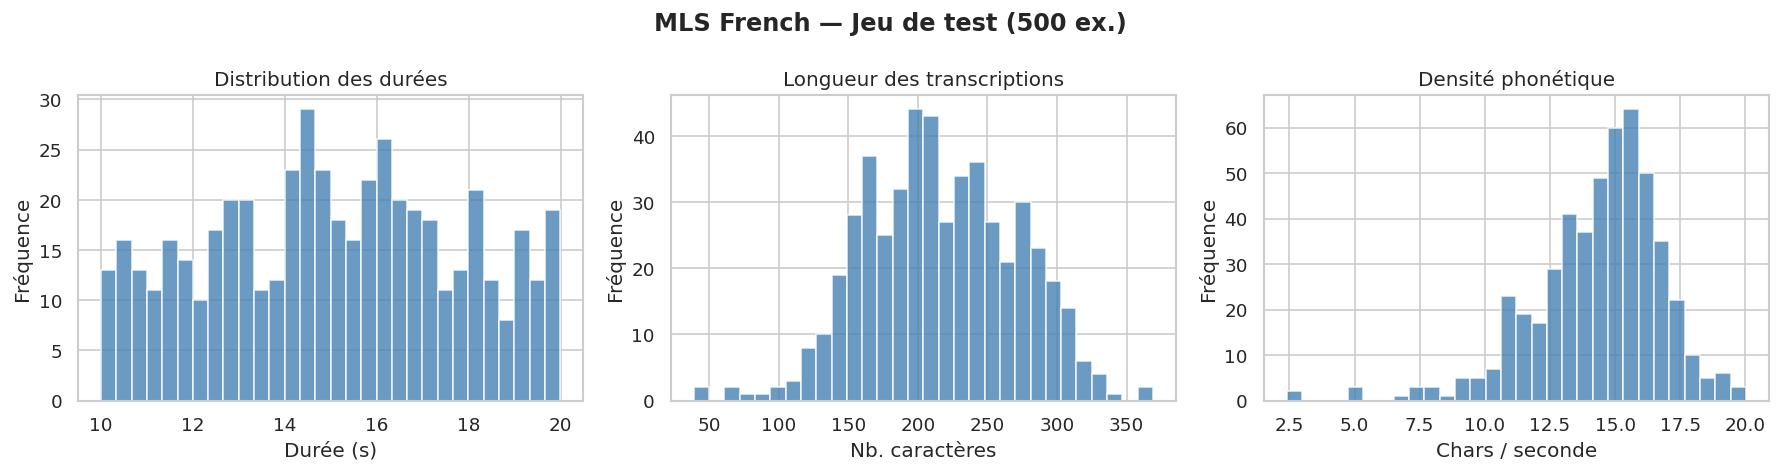

       duration  n_chars  chars_per_sec
count    500.00   500.00         500.00
mean      15.06   216.32          14.36
std        2.70    54.49           2.45
min       10.00    39.00           2.39
25%       12.86   177.00          13.13
50%       15.06   212.00          14.78
75%       17.08   256.00          15.95
max       19.99   369.00          20.02


In [11]:
def get_stats(ex):
    return {"duration": len(ex["audio"]["array"])/SAMPLE_RATE,
            "n_chars":  len(ex["sentence"])}

df_test = mls_test.map(get_stats).to_pandas()[["duration","n_chars","sentence"]]
df_test["chars_per_sec"] = df_test["n_chars"] / df_test["duration"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, xlabel, title in zip(
    axes,
    ["duration", "n_chars", "chars_per_sec"],
    ["Durée (s)", "Nb. caractères", "Chars / seconde"],
    ["Distribution des durées", "Longueur des transcriptions", "Densité phonétique"]
):
    ax.hist(df_test[col], bins=30, color='steelblue', alpha=0.8, edgecolor='white')
    ax.set(xlabel=xlabel, ylabel="Fréquence", title=title)
plt.suptitle("MLS French — Jeu de test (500 ex.)", fontweight='bold')
plt.tight_layout()
save_fig("fig_eda.png"); plt.show()

print(df_test[["duration","n_chars","chars_per_sec"]].describe().round(2))


---
## 4. Évaluation baseline — Whisper <a id='section4'></a>
> ⏭️ **Sautez si §0 affiche `✅ baseline`.**

In [12]:
def normalize_text(text: str) -> str:
    text = text.lower().strip()
    text = re.sub(r"[\.,;:!?'\"\-\(\)]", "", text)
    return re.sub(r"\s+", " ", text)

def evaluate_whisper(model_name, dataset, language="fr", batch_size=8):
    print(f"\n── {Path(model_name).name} | lang={language} | {len(dataset)} ex. ──")
    proc  = WhisperProcessor.from_pretrained(model_name, language=language, task="transcribe")
    # Charger en float32 explicitement pour éviter le mismatch fp16/fp32
    # (large-v3 a ses biais en fp16 par défaut, ce qui cause un RuntimeError)
    model = WhisperForConditionalGeneration.from_pretrained(
        model_name, torch_dtype=torch.float32
    ).eval().to(DEVICE)
    model.config.forced_decoder_ids = None
    model.generation_config.language = language
    model.generation_config.task     = "transcribe"
    # Supprimer max_length du generation_config pour éviter le warning
    model.generation_config.max_length = None
    refs, hyps = [], []
    for i in range(0, len(dataset), batch_size):
        batch  = dataset[i: i+batch_size]
        arrays = [a["array"] for a in batch["audio"]]
        # Traiter chaque audio individuellement pour garantir 3000 bins (30s pad/trunc)
        input_list = [
            proc(a, sampling_rate=SAMPLE_RATE, return_tensors="pt",
                 return_attention_mask=False).input_features
            for a in arrays
        ]
        # input_features est float32 par défaut — cohérent avec torch_dtype=float32
        input_features = torch.cat(input_list, dim=0).to(DEVICE)
        with torch.no_grad():
            ids = model.generate(
                input_features,
                max_new_tokens=225,
                language=language,
                task="transcribe",
            )
        hyps.extend([normalize_text(p) for p in proc.batch_decode(ids, skip_special_tokens=True)])
        refs.extend([normalize_text(r) for r in batch["sentence"]])
        if (i//batch_size) % 10 == 0:
            print(f"  {min(i+batch_size,len(dataset))}/{len(dataset)} …")
    w, c = wer(refs, hyps), cer(refs, hyps)
    print(f"  ➜ WER={w*100:.2f}%  CER={c*100:.2f}%")
    del model; torch.cuda.empty_cache()
    return {"wer": w, "cer": c, "references": refs, "hypotheses": hyps}

print("✅ Fonctions baseline définies")

✅ Fonctions baseline définies


In [13]:
#baseline_results = None
#_refs_hyps = {}
#wandb.finish()
#print("✅ Reset fait")

In [14]:
# Garde le GPU actif pendant l'inférence — empêche Colab de déconnecter
import IPython
js_code = """
function ClickConnect(){
    console.log("Keeping Colab alive...");
    document.querySelector("#top-toolbar > colab-connect-button")
        ?.shadowRoot?.querySelector("#connect")?.click();
}
setInterval(ClickConnect, 60000);
"""
IPython.display.display(IPython.display.Javascript(js_code))
print("✅ Anti-déconnexion actif")

<IPython.core.display.Javascript object>

✅ Anti-déconnexion actif


In [15]:
if baseline_results is not None:
    print("⏭️  Baseline déjà disponible depuis WandB — section sautée.")
else:
    MODELS = {
        "small"   : ("openai/whisper-small",    16),
        "medium"  : ("openai/whisper-medium",    8),
        "large-v3": ("openai/whisper-large-v3",  4),
    }
    baseline_results = {}
    _refs_hyps = {}  # conservé en mémoire pour §5, non persisté dans l'artifact

    run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY,
                     name="baseline-evaluation", reinit="finish_previous",
                     config={"n_test": N_TEST, "models": list(MODELS.keys())})

    for variant, (model_id, bs) in MODELS.items():
        for lang_key, ds in {"fr": cv_fr["test"], "fr-CA": cv_frca["test"]}.items():
            key = f"{variant}/{lang_key}"
            res = evaluate_whisper(model_id, ds, batch_size=bs)
            baseline_results[key] = {"wer": res["wer"], "cer": res["cer"]}
            _refs_hyps[key]       = (res["references"], res["hypotheses"])
            run.log({f"baseline/{key}/wer": res["wer"],
                     f"baseline/{key}/cer": res["cer"]})

    bl_json = f"{LOCAL_CKPT_DIR}/baseline_results.json"
    save_json(baseline_results, bl_json)
    save_artifact("baseline", "evaluation",
                  {"baseline_results.json": bl_json},
                  metadata={"n_test": N_TEST}, run=run)
    wandb.finish()
    print("\n✅ Baseline sauvegardée sur WandB")

⏭️  Baseline déjà disponible depuis WandB — section sautée.


Variante  WER (%)  CER (%)
   small    14.48     6.55
  medium     9.38     4.05
large-v3     6.17     3.99


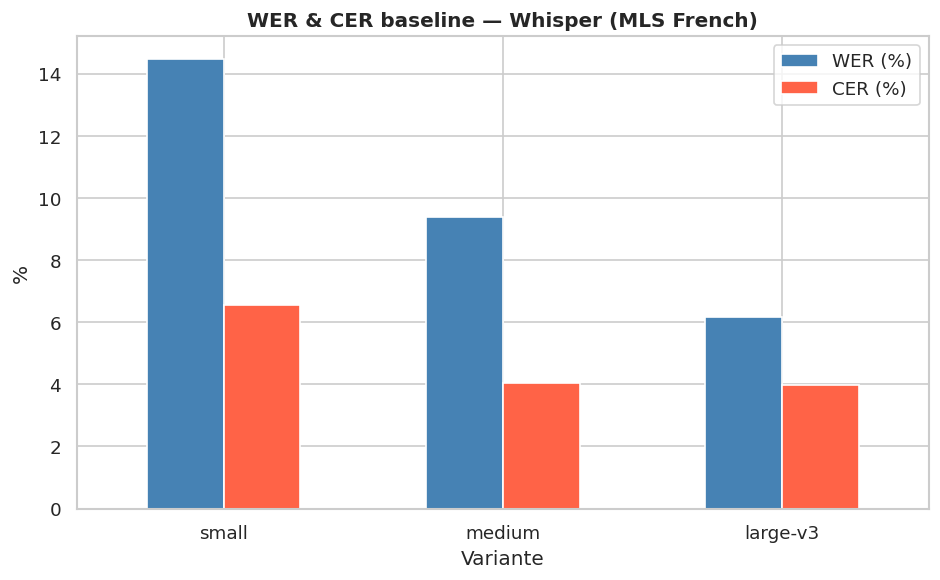

In [16]:
rows = [{
    "Variante": k.split("/")[0],
    "WER (%)": round(v["wer"]*100, 2),
    "CER (%)": round(v["cer"]*100, 2)
} for k, v in baseline_results.items() if k.endswith("/fr")]  # ← filtre fr-CA

df_baseline = pd.DataFrame(rows)
print(df_baseline.to_string(index=False))

pivot = df_baseline.set_index("Variante")[["WER (%)", "CER (%)"]]
ax = pivot.plot(kind="bar", figsize=(8, 5), color=["steelblue", "tomato"],
                edgecolor="white", width=0.55)
ax.set_title("WER & CER baseline — Whisper (MLS French)", fontweight="bold")
ax.set_xlabel("Variante"); ax.set_ylabel("%")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
save_fig("fig_baseline.png"); plt.show()

---
## 4b. Scaling laws & compromis vitesse/précision <a id='section_scaling'></a>


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensA

  small        |   244M params | WER=14.48% | latence=1220ms


Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

  medium       |   769M params | WER=9.38% | latence=2740ms


Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

  large-v3     |  1550M params | WER=6.17% | latence=3063ms


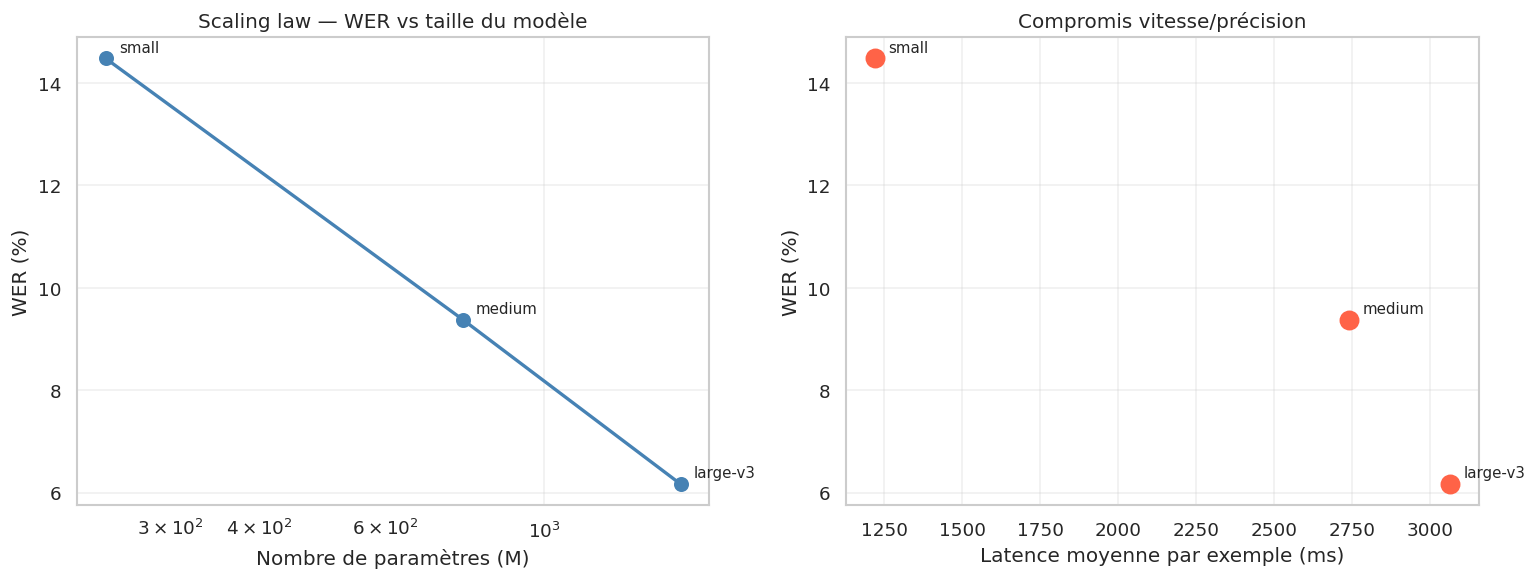

In [17]:
import time

# Paramètres des variantes Whisper
MODEL_PARAMS = {
    "openai/whisper-small":    244,   # M paramètres
    "openai/whisper-medium":   769,
    "openai/whisper-large-v3": 1550,
}

scaling_results = {}
N_LATENCY = 20  # exemples pour mesure de latence (subset léger)

for model_name, n_params in MODEL_PARAMS.items():
    variant = model_name.split("/")[1].replace("whisper-","")
    wer_val  = baseline_results[f"{variant}/fr"]["wer"] * 100
    cer_val  = baseline_results[f"{variant}/fr"]["cer"] * 100

    # Mesure du temps d'inférence sur N_LATENCY exemples
    proc  = WhisperProcessor.from_pretrained(model_name, language="fr", task="transcribe")
    model = WhisperForConditionalGeneration.from_pretrained(
        model_name, torch_dtype=torch.float32).eval().to(DEVICE)
    subset = mls_test.select(range(N_LATENCY))
    t0 = time.time()
    for ex in subset:
        inp = proc(ex["audio"]["array"], sampling_rate=SAMPLE_RATE,
                   return_tensors="pt").input_features.to(DEVICE)
        with torch.no_grad():
            model.generate(inp, language="fr", task="transcribe")
    latency_ms = (time.time() - t0) / N_LATENCY * 1000
    del model; torch.cuda.empty_cache()

    scaling_results[variant] = {"params_M": n_params, "wer": wer_val,
                                  "cer": cer_val, "latency_ms": latency_ms}
    print(f"  {variant:12} | {n_params:5}M params | WER={wer_val:.2f}% | latence={latency_ms:.0f}ms")

# ── Graphiques scaling ────────────────────────────────────────────────────────
names    = list(scaling_results.keys())
params   = [scaling_results[n]["params_M"] for n in names]
wers     = [scaling_results[n]["wer"] for n in names]
latences = [scaling_results[n]["latency_ms"] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# WER vs paramètres
axes[0].plot(params, wers, 'o-', color='steelblue', linewidth=2, markersize=8)
for n, p, w in zip(names, params, wers):
    axes[0].annotate(n, (p, w), textcoords='offset points', xytext=(8, 4), fontsize=9)
axes[0].set(xlabel="Nombre de paramètres (M)", ylabel="WER (%)",
            title="Scaling law — WER vs taille du modèle", xscale='log')
axes[0].grid(True, alpha=0.3)

# WER vs latence
axes[1].scatter(latences, wers, s=120, c='tomato', zorder=5)
for n, l, w in zip(names, latences, wers):
    axes[1].annotate(n, (l, w), textcoords='offset points', xytext=(8, 4), fontsize=9)
axes[1].set(xlabel="Latence moyenne par exemple (ms)", ylabel="WER (%)",
            title="Compromis vitesse/précision")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_fig("fig_scaling.png"); plt.show()


---
## 5. Analyse du profil d'erreurs de Whisper <a id='section5'></a>


Recalcul Whisper small sur MLS test pour l'analyse des erreurs …

── whisper-small | lang=fr | 500 ex. ──


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Both `max_new_tokens` (=225) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  16/500 …


Both `max_new_tokens` (=225) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=225) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=225) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=225) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

...

  336/500 …


Both `max_new_tokens` (=225) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=225) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=225) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=225) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

  496/500 …


Both `max_new_tokens` (=225) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  ➜ WER=14.48%  CER=6.55%
   WER  Référence                            Hypothèse
────────────────────────────────────────────────────────────────────────────────
  1.56  sa queue sétait enfoncée dans un …   sa queue sétait enfoncée dans un tonneau de g
  1.56  et tout de suite il lui demanda s…   et tout de suite il lui demanda sa main fin d
  1.17  moineau dans un champ de millet l…   chapitre xiv de abc petit compte de jules de 
  1.00  oreille quand noé eut rassemblé l…   chapitre xvi
  0.97  chapitre vingt de a b c petits co…   chapitre v i
  0.97  chapitre vingt cinq de a b c peti…   chapitre 25
  0.97  chapitre vingt trois de a b c pet…   chapitre 23
  0.97  chapitre dix huit de a b c petits…   chapitre xviii
  0.83  cest bien ennuyeux fin du chapitr…   cest bien ennuyeux
  0.81  zéro dans la vie quand on nest bo…   chapitre 26 a b c petit compte jule maître en
  0.81  elle se sauva pour donner libre c…   elle se sauva pour donner libre courage aux o
  0.68  pendant quil parlait 

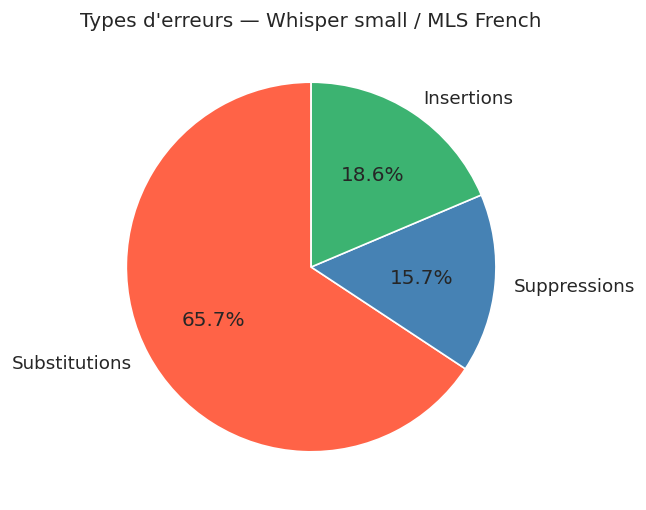

Sub: 1838 (65.7%) | Del: 438 (15.7%) | Ins: 521 (18.6%)

── WER stratifié par durée ──
  court  (10-13s, n=130) → WER = 14.97%
  moyen  (13-16s, n=174) → WER = 18.48%
  long   (16-20s, n=196) → WER = 15.20%


In [18]:
from jiwer import process_words
from collections import Counter

# Recalcul ou récupération des refs/hyps de Whisper small
try:
    refs, hyps = _refs_hyps["small/fr"]
except (NameError, KeyError):
    print("Recalcul Whisper small sur MLS test pour l'analyse des erreurs …")
    res = evaluate_whisper("openai/whisper-small", mls_test, batch_size=16)
    refs, hyps = res["references"], res["hypotheses"]

# ── Top-15 pires exemples ─────────────────────────────────────────────────────
worst = sorted([(wer([r],[h]),r,h) for r,h in zip(refs,hyps)], reverse=True)
print(f"{'WER':>6}  {'Référence':<35}  Hypothèse\n" + "─"*80)
for ws, ref, hyp in worst[:15]:
    print(f"{ws:6.2f}  {(ref[:33]+'…') if len(ref)>35 else ref:<35}  {hyp[:45]}")

# ── Distribution des types d'erreurs ─────────────────────────────────────────
S=D=I=H=0
for ref, hyp in zip(refs, hyps):
    o=process_words(ref,hyp); S+=o.substitutions; D+=o.deletions; I+=o.insertions; H+=o.hits
total=S+D+I
fig, ax = plt.subplots(figsize=(5,5))
ax.pie([S,D,I], labels=["Substitutions","Suppressions","Insertions"],
       autopct='%1.1f%%', colors=["tomato","steelblue","mediumseagreen"], startangle=90)
ax.set_title("Types d'erreurs — Whisper small / MLS French")
save_fig("fig_error_types.png"); plt.show()
print(f"Sub: {S} ({100*S/total:.1f}%) | Del: {D} ({100*D/total:.1f}%) | Ins: {I} ({100*I/total:.1f}%)")

# ── Stratification WER par durée d'audio ─────────────────────────────────────
import numpy as np
durations = [len(mls_test[i]['audio']['array'])/SAMPLE_RATE for i in range(len(mls_test))]
wers_per_ex = [wer([r],[h]) for r,h in zip(refs,hyps)]
buckets = [(10,13,'court'),(13,16,'moyen'),(16,20,'long')]
print("\n── WER stratifié par durée ──")
for lo, hi, label in buckets:
    idx = [i for i,d in enumerate(durations) if lo<=d<hi]
    if idx:
        print(f"  {label:6} ({lo}-{hi}s, n={len(idx):3}) → WER = {np.mean([wers_per_ex[i] for i in idx])*100:.2f}%")


---
## 6. Fine-tuning — Whisper small sur MLS French <a id='section6'></a>
> ⏭️ **Sautez si §0 affiche `✅ finetuning`.**

Objectif : quantifier le gain apporté par l'adaptation supervisée avec un budget de données limité (2 000 exemples).


In [19]:
feature_extractor = WhisperFeatureExtractor.from_pretrained(MODEL_FT)
tokenizer  = WhisperTokenizer.from_pretrained(MODEL_FT, language="French", task="transcribe")
processor  = WhisperProcessor.from_pretrained(MODEL_FT, language="French", task="transcribe")
metric_wer = evaluate.load("wer")

def prepare_dataset(batch):
    audio = batch["audio"]
    batch["input_features"] = feature_extractor(
        audio["array"], sampling_rate=audio["sampling_rate"]).input_features[0]
    batch["labels"] = tokenizer(batch["sentence"]).input_ids
    return batch

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any
    decoder_start_token_id: int
    def __call__(self, features):
        inp  = [{"input_features": f["input_features"]} for f in features]
        bat  = self.processor.feature_extractor.pad(inp, return_tensors="pt")
        lbl  = self.processor.tokenizer.pad(
                   [{"input_ids": f["labels"]} for f in features], return_tensors="pt")
        l    = lbl["input_ids"].masked_fill(lbl.attention_mask.ne(1), -100)
        if (l[:, 0] == self.decoder_start_token_id).all().cpu().item():
            l = l[:, 1:]
        bat["labels"] = l
        return bat

def compute_metrics(pred):
    pid = pred.predictions; lid = pred.label_ids
    lid[lid == -100] = tokenizer.pad_token_id
    ps = [normalize_text(p) for p in tokenizer.batch_decode(pid, skip_special_tokens=True)]
    ls = [normalize_text(l) for l in tokenizer.batch_decode(lid, skip_special_tokens=True)]
    return {"wer": 100 * metric_wer.compute(predictions=ps, references=ls)}

print("✅ Composants fine-tuning prêts")

✅ Composants fine-tuning prêts


In [20]:
if ft_result is not None:
    print(f"⏭️  Fine-tuning déjà disponible depuis WandB.")
    print(f"   WER test = {ft_result['wer']*100:.2f}%  |  Modèle : {FT_MODEL_PATH}")
else:
    FT_LR, FT_BS, FT_EPOCHS = 1e-5, 16, 5
    FT_MODEL_PATH = f"{LOCAL_CKPT_DIR}/whisper-small-mls"

    print("Préparation des données …")
    train_ds = mls_train.map(prepare_dataset,
        remove_columns=mls_train.column_names, num_proc=1)
    val_ds   = mls_val.map(prepare_dataset,
        remove_columns=mls_val.column_names, num_proc=1)

    model_ft = WhisperForConditionalGeneration.from_pretrained(MODEL_FT)
    model_ft.generation_config.forced_decoder_ids = None
    model_ft.generation_config.suppress_tokens = []
    collator = DataCollatorSpeechSeq2SeqWithPadding(
        processor=processor,
        decoder_start_token_id=model_ft.config.decoder_start_token_id)

    run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY,
                     name=f"fine-tuning-lr{FT_LR}", reinit="finish_previous",
                     config={"lr": FT_LR, "epochs": FT_EPOCHS, "batch_size": FT_BS,
                             "model": MODEL_FT, "dataset": "mls-french"})

    trainer = Seq2SeqTrainer(
        model=model_ft, args=Seq2SeqTrainingArguments(
            output_dir=FT_MODEL_PATH,
            per_device_train_batch_size=FT_BS, per_device_eval_batch_size=8,
            learning_rate=FT_LR, warmup_steps=500,
            num_train_epochs=FT_EPOCHS,
            gradient_checkpointing=True, fp16=True,
            eval_strategy="epoch", save_strategy="epoch",
            load_best_model_at_end=True, metric_for_best_model="wer", greater_is_better=False,
            predict_with_generate=True, generation_max_length=225,
            logging_steps=25, report_to=["wandb"],
            run_name=f"whisper-small-mls-lr{FT_LR}",
            push_to_hub=False, label_names=["labels"],
        ),
        train_dataset=train_ds, eval_dataset=val_ds,
        #tokenizer=processor.feature_extractor,
        data_collator=collator, compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )
    trainer.train()
    trainer.save_model()
    processor.save_pretrained(FT_MODEL_PATH)

    # Courbes d'apprentissage
    lt = [l for l in trainer.state.log_history if "loss" in l and "eval_loss" not in l]
    le = [l for l in trainer.state.log_history if "eval_wer" in l]
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    if lt: axes[0].plot([l["step"] for l in lt], [l["loss"] for l in lt], color="steelblue")
    axes[0].set(title="Train Loss", xlabel="Step", ylabel="Loss")
    if le: axes[1].plot([l["epoch"] for l in le], [l["eval_wer"] for l in le],
                        marker='o', color="tomato")
    axes[1].set(title="WER validation", xlabel="Époque", ylabel="WER (%)")
    plt.tight_layout()
    fig_curves = save_fig("fig_training_curves.png"); plt.show()

    # Évaluation finale test
    res_ft    = evaluate_whisper(FT_MODEL_PATH, mls_test, batch_size=8)
    ft_result = {"wer": res_ft["wer"], "cer": res_ft["cer"]}
    run.log({"test/wer": ft_result["wer"], "test/cer": ft_result["cer"]})

    # ── Sauvegarde artifact (JSON + modèle + figure) ──────────────────────────
    ft_json = f"{LOCAL_CKPT_DIR}/ft_result.json"
    save_json(ft_result, ft_json)
    save_artifact("finetuning", "model",
                  {"ft_result.json":          ft_json,
                   "model":                   FT_MODEL_PATH,
                   "fig_training_curves.png": fig_curves},
                  metadata={"wer": ft_result["wer"], "lr": FT_LR, "epochs": FT_EPOCHS},
                  run=run)
    wandb.finish()
    del model_ft; torch.cuda.empty_cache()
    print(f"\n✅ Fine-tuning terminé | WER test = {ft_result['wer']*100:.2f}%")

⏭️  Fine-tuning déjà disponible depuis WandB.
   WER test = 13.41%  |  Modèle : /content/resumed/finetuning/model


In [21]:
bl = baseline_results["small/fr"]
print(f"{'':26} {'WER (%)':>8}  {'CER (%)':>8}\n" + "─"*46)
print(f"{'Whisper small baseline':26} {bl['wer']*100:8.2f}  {bl['cer']*100:8.2f}")
print(f"{'Whisper small fine-tuné':26} {ft_result['wer']*100:8.2f}  {ft_result['cer']*100:8.2f}")
delta = (ft_result['wer'] - bl['wer']) * 100
print(f"\nΔ WER : {delta:+.2f} pp  |  Réduction relative : {delta/bl['wer']/100*100:.1f}%")
print("\nNote : les deux modèles sont évalués sur le même jeu de test MLS French (500 ex.)")


                            WER (%)   CER (%)
──────────────────────────────────────────────
Whisper small baseline        14.48      6.55
Whisper small fine-tuné       13.41      6.12

Δ WER : -1.07 pp  |  Réduction relative : -7.4%

Note : les deux modèles sont évalués sur le même jeu de test MLS French (500 ex.)


---
## 7. Ablations & hyperparamètres <a id='section7'></a>
> ⏭️ Chaque sous-section vérifie **son propre artifact** indépendamment.

Trois ablations sont conduites pour comprendre la sensibilité du fine-tuning :
1. **Taux d'apprentissage** (1e-5, 3e-5, 5e-5)
2. **Gel de l'encodeur** — adapter uniquement le décodeur vs le modèle complet
3. **Augmentation audio** — AddGaussianNoise + TimeStretch + PitchShift


In [22]:
# Reset VRAM
import gc
for name in list(globals().keys()):
    if isinstance(globals()[name], torch.nn.Module):
        del globals()[name]
gc.collect()
torch.cuda.empty_cache()
print(f"VRAM libre : {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

VRAM libre : 15.5 GB


In [23]:
# Datasets & collator — recréés si on arrive ici après une reprise
try:
    _ = train_ds
except NameError:
    print("Préparation des datasets pour ablations …")
    train_ds = cv_frca["train"].map(prepare_dataset,
                   remove_columns=cv_frca["train"].column_names, num_proc=1)
    val_ds   = cv_frca["validation"].map(prepare_dataset,
                   remove_columns=cv_frca["validation"].column_names, num_proc=1)
    _tmp = WhisperForConditionalGeneration.from_pretrained(MODEL_FT)
    collator = DataCollatorSpeechSeq2SeqWithPadding(
        processor=processor, decoder_start_token_id=_tmp.config.decoder_start_token_id)
    del _tmp
    print("✅ Datasets prêts")

def run_ablation(label, lr=1e-5, freeze_enc=False, train_data=None, n_epochs=2):
    import gc
    gc.collect(); torch.cuda.empty_cache()
    print(f"  VRAM libre : {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

    m = WhisperForConditionalGeneration.from_pretrained(
        MODEL_FT, torch_dtype=torch.float32)
    m.config.forced_decoder_ids      = None
    m.generation_config.forced_decoder_ids = None
    m.generation_config.suppress_tokens   = []
    m.generation_config.language          = "fr"
    m.generation_config.task              = "transcribe"

    if freeze_enc:
        for p in m.model.encoder.parameters():
            p.requires_grad = False

    t = Seq2SeqTrainer(
        model=m,
        args=Seq2SeqTrainingArguments(
            output_dir=f"/content/abl_{label}",
            per_device_train_batch_size=2,
            gradient_accumulation_steps=8,
            per_device_eval_batch_size=2,
            learning_rate=lr,
            warmup_steps=50,
            num_train_epochs=n_epochs,
            fp16=True,
            optim="adafactor",
            gradient_checkpointing=True,
            eval_strategy="epoch",
            save_strategy="no",
            predict_with_generate=True,
            generation_max_length=225,
            logging_steps=50,
            report_to=["wandb"],
            run_name=f"ablation-{label}",
            label_names=["labels"],
            dataloader_num_workers=0,
        ),
        train_dataset=train_data or train_ds,
        eval_dataset=val_ds,
        processing_class=processor.feature_extractor,
        data_collator=collator,
        compute_metrics=compute_metrics,
    )
    t.train()
    res = t.evaluate()
    del m, t
    gc.collect(); torch.cuda.empty_cache()
    return res["eval_wer"]

print("✅ run_ablation OK")

Préparation des datasets pour ablations …


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

✅ Datasets prêts
✅ run_ablation OK


In [24]:
#ablation_lr_results = None

⏭️  Ablation LR déjà disponible depuis WandB :
  LR=1e-05 → WER=12.58%
  LR=3e-05 → WER=13.14%
  LR=5e-05 → WER=13.71%


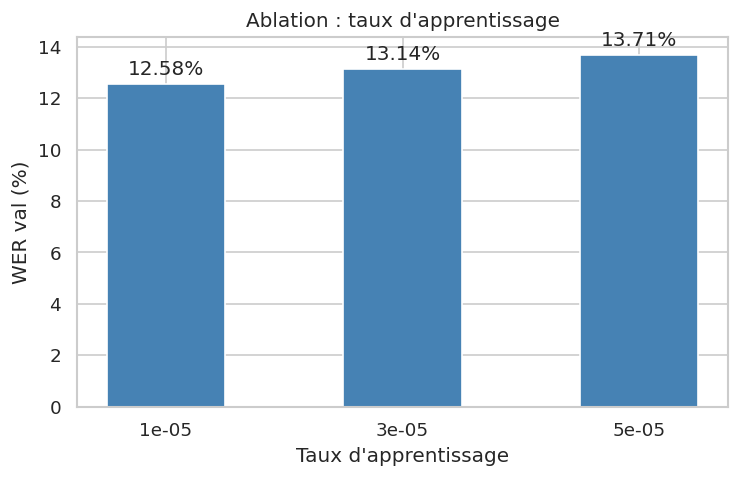

In [25]:
# ── Ablation 1 : Taux d'apprentissage ───────────────────────────────────────
if ablation_lr_results is not None:
    print("⏭️  Ablation LR déjà disponible depuis WandB :")
    for lr, w in ablation_lr_results.items(): print(f"  LR={lr} → WER={w:.2f}%")
else:
    # Vider la VRAM avant de commencer (le modèle FT peut encore être en mémoire)
    torch.cuda.empty_cache()
    import gc; gc.collect()
    print(f"VRAM libre : {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

    LEARNING_RATES   = [1e-5, 3e-5, 5e-5]
    ablation_lr_results = {}
    run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY,
                     name="ablation-lr", reinit="finish_previous")
    for lr in LEARNING_RATES:
        print(f"\n── LR={lr} ──")
        w = run_ablation(f"lr{lr}", lr=lr)
        ablation_lr_results[lr] = w
        run.log({f"ablation/lr/{lr}/wer": w})
        print(f"  LR={lr} → WER={w:.2f}%")
    abl_json = f"{LOCAL_CKPT_DIR}/ablation_lr.json"
    save_json({str(k): v for k,v in ablation_lr_results.items()}, abl_json)
    save_artifact("ablation-lr", "ablation",
                  {"ablation_lr.json": abl_json},
                  metadata={"learning_rates": list(ablation_lr_results.keys())}, run=run)
    wandb.finish()

fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar([str(lr) for lr in ablation_lr_results],
              list(ablation_lr_results.values()),
              color="steelblue", edgecolor="white", width=0.5)
ax.bar_label(bars, fmt='%.2f%%', padding=3)
ax.set(xlabel="Taux d'apprentissage", ylabel="WER val (%)",
       title="Ablation : taux d'apprentissage")
save_fig("fig_ablation_lr.png"); plt.show()


In [26]:
# ── Ablation 2 : Gel de l'encodeur ────────────────────────────────────────────
if ablation_freeze_results is not None:
    print("⏭️  Ablation freeze déjà disponible depuis WandB :")
    for k, v in ablation_freeze_results.items(): print(f"  {k} → WER={v:.2f}%")
else:
    ablation_freeze_results = {}
    run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY,
                     name="ablation-freeze", reinit="finish_previous")
    for freeze, label in [(False,"encodeur_libre"),(True,"encodeur_gelé")]:
        w = run_ablation(label, lr=1e-5, freeze_enc=freeze)
        ablation_freeze_results[label] = w
        run.log({f"ablation/freeze/{label}/wer": w})
        print(f"  {label} → WER={w:.2f}%")
    frz_json = f"{LOCAL_CKPT_DIR}/ablation_freeze.json"
    save_json(ablation_freeze_results, frz_json)
    save_artifact("ablation-freeze", "ablation",
                  {"ablation_freeze.json": frz_json}, run=run)
    wandb.finish()

⏭️  Ablation freeze déjà disponible depuis WandB :
  encodeur_libre → WER=12.58%
  encodeur_gelé → WER=13.50%


In [27]:
# ── Ablation 3 : Augmentation audio ───────────────────────────────────────────
if ablation_aug_wer is not None:
    print(f"⏭️  Ablation augmentation déjà disponible : WER={ablation_aug_wer:.2f}%")
else:
    from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift
    augment = Compose([
        AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.5),
        TimeStretch(min_rate=0.9, max_rate=1.1, p=0.3),
        PitchShift(min_semitones=-2, max_semitones=2, p=0.3),
    ])
    def prepare_aug(batch):
        audio = batch["audio"]
        arr   = augment(samples=audio["array"].astype(np.float32),
                        sample_rate=audio["sampling_rate"])
        batch["input_features"] = feature_extractor(
            arr, sampling_rate=audio["sampling_rate"]).input_features[0]
        batch["labels"] = tokenizer(batch["sentence"]).input_ids
        return batch
    train_aug = cv_frca["train"].map(prepare_aug,
                    remove_columns=cv_frca["train"].column_names)

    run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY,
                     name="ablation-augmentation", reinit="finish_previous")
    ablation_aug_wer = run_ablation("augmented", lr=1e-5, train_data=train_aug)
    run.log({"ablation/augment/wer": ablation_aug_wer})

    aug_json = f"{LOCAL_CKPT_DIR}/ablation_augment.json"
    save_json({"wer": ablation_aug_wer}, aug_json)
    save_artifact("ablation-augment", "ablation",
                  {"ablation_augment.json": aug_json},
                  metadata={"wer": ablation_aug_wer}, run=run)
    wandb.finish()
    print(f"✅ WER augmentation = {ablation_aug_wer:.2f}%")

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

  VRAM libre : 15.5 GB


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Wer
1,2.518831,0.260715,12.366058
2,1.474733,0.253889,11.866493


  💾 Artifact 'inf8225-whisper-french-ablation-augment' sauvegardé sur WandB


ablation/augment/wer,▁
eval/loss,█▁▁
eval/runtime,▂█▁
eval/samples_per_second,▆▁█
eval/steps_per_second,▆▁█
eval/wer,█▁▁
train/epoch,▁▃▄▅▆████
train/global_step,▁▃▄▅▆█████
train/grad_norm,▇█▂▁▁
train/learning_rate,█▇▅▃▁
+1,...


✅ WER augmentation = 11.87%


In [28]:
# ── Tableau récapitulatif des ablations ───────────────────────────────────────
bl_wer = baseline_results["small/fr-CA"]["wer"] * 100

abl_rows = [
    {"Expérience": "Baseline (sans FT)",         "WER val (%)": round(bl_wer, 2),      "Δ pp": "—"},
    {"Expérience": "FT lr=1e-5",  "WER val (%)": round(ablation_lr_results.get(1e-5, float('nan')),2),
     "Δ pp": f"{ablation_lr_results.get(1e-5,0)-bl_wer:+.2f}"},
    {"Expérience": "FT lr=3e-5",  "WER val (%)": round(ablation_lr_results.get(3e-5, float('nan')),2),
     "Δ pp": f"{ablation_lr_results.get(3e-5,0)-bl_wer:+.2f}"},
    {"Expérience": "FT lr=5e-5",  "WER val (%)": round(ablation_lr_results.get(5e-5, float('nan')),2),
     "Δ pp": f"{ablation_lr_results.get(5e-5,0)-bl_wer:+.2f}"},
    {"Expérience": "FT encodeur libre", "WER val (%)": round(ablation_freeze_results.get('encodeur_libre',float('nan')),2),
     "Δ pp": f"{ablation_freeze_results.get('encodeur_libre',0)-bl_wer:+.2f}"},
    {"Expérience": "FT encodeur gelé",  "WER val (%)": round(ablation_freeze_results.get('encodeur_gelé',float('nan')),2),
     "Δ pp": f"{ablation_freeze_results.get('encodeur_gelé',0)-bl_wer:+.2f}"},
    {"Expérience": "FT + augmentation audio", "WER val (%)": round(ablation_aug_wer,2),
     "Δ pp": f"{ablation_aug_wer-bl_wer:+.2f}"},
]
abl_df = pd.DataFrame(abl_rows)
print("\n══════════ TABLEAU D'ABLATIONS ══════════")
print(abl_df.to_string(index=False))
abl_df.to_csv(f"{LOCAL_CKPT_DIR}/ablation_results.csv", index=False)


══════════ TABLEAU D'ABLATIONS ══════════
             Expérience  WER val (%)  Δ pp
     Baseline (sans FT)        14.48     —
             FT lr=1e-5        12.58 -1.90
             FT lr=3e-5        13.14 -1.34
             FT lr=5e-5        13.71 -0.77
      FT encodeur libre        12.58 -1.90
       FT encodeur gelé        13.50 -0.98
FT + augmentation audio        11.87 -2.61


---
## 8. Comparaison avec wav2vec 2.0 <a id='section8'></a>
> ⏭️ **Sautez si §0 affiche `✅ wav2vec`.**

In [29]:
def evaluate_wav2vec(model_name, dataset, batch_size=8):
    print(f"\n── wav2vec 2.0 | {len(dataset)} ex. ──")
    proc  = Wav2Vec2Processor.from_pretrained(model_name)
    model = Wav2Vec2ForCTC.from_pretrained(
        model_name, torch_dtype=torch.float32
    ).eval().to(DEVICE)
    refs, hyps = [], []
    for i in range(0, len(dataset), batch_size):
        batch  = dataset[i: i+batch_size]
        inputs = proc([a["array"] for a in batch["audio"]],
                      sampling_rate=SAMPLE_RATE, return_tensors="pt",
                      padding=True).to(DEVICE)
        # S'assurer que les inputs sont en float32
        inputs = {k: v.float() if v.dtype == torch.float16 else v
                  for k, v in inputs.items()}
        with torch.no_grad():
            logits = model(**inputs).logits
        hyps.extend([normalize_text(p) for p in proc.batch_decode(torch.argmax(logits,-1))])
        refs.extend([normalize_text(r) for r in batch["sentence"]])
        if (i//batch_size) % 10 == 0:
            print(f"  {min(i+batch_size,len(dataset))}/{len(dataset)} …")
    w, c = wer(refs, hyps), cer(refs, hyps)
    print(f"  WER={w*100:.2f}%  CER={c*100:.2f}%")
    del model; torch.cuda.empty_cache()
    return {"wer": w, "cer": c}


---
## 9. Synthèse des résultats <a id='section9'></a>


In [30]:
rows = []
for variant in ["small","medium","large-v3"]:
    res = baseline_results.get(f"{variant}/fr")
    if res:
        rows.append({"Modèle": f"Whisper {variant}", "Fine-tuning": "Non",
                     "WER (%)": round(res["wer"]*100,2),
                     "CER (%)": round(res["cer"]*100,2)})
    if ft_result:
        rows.append({"Modèle": "Whisper small", "Fine-tuning": "Oui (MLS 2k)",
                    "WER (%)": round(ft_result["wer"]*100,2),
                    "CER (%)": round(ft_result["cer"]*100,2)})
    if w2v_fr:
        rows.append({"Modèle": "wav2vec 2.0 XLSR-53", "Fine-tuning": "Non",
                    "WER (%)": round(w2v_fr["wer"]*100,2),
                    "CER (%)": round(w2v_fr["cer"]*100,2)})

df_synth = pd.DataFrame(rows)
print("═"*50 + "\n     SYNTHÈSE DES RÉSULTATS — MLS FRENCH\n" + "═"*50)
print(df_synth.to_string(index=False))
df_synth.to_csv(f"{LOCAL_CKPT_DIR}/synthesis_results.csv", index=False)


══════════════════════════════════════════════════
     SYNTHÈSE DES RÉSULTATS — MLS FRENCH
══════════════════════════════════════════════════
          Modèle  Fine-tuning  WER (%)  CER (%)
   Whisper small          Non    14.48     6.55
   Whisper small Oui (MLS 2k)    13.41     6.12
  Whisper medium          Non     9.38     4.05
   Whisper small Oui (MLS 2k)    13.41     6.12
Whisper large-v3          Non     6.17     3.99
   Whisper small Oui (MLS 2k)    13.41     6.12


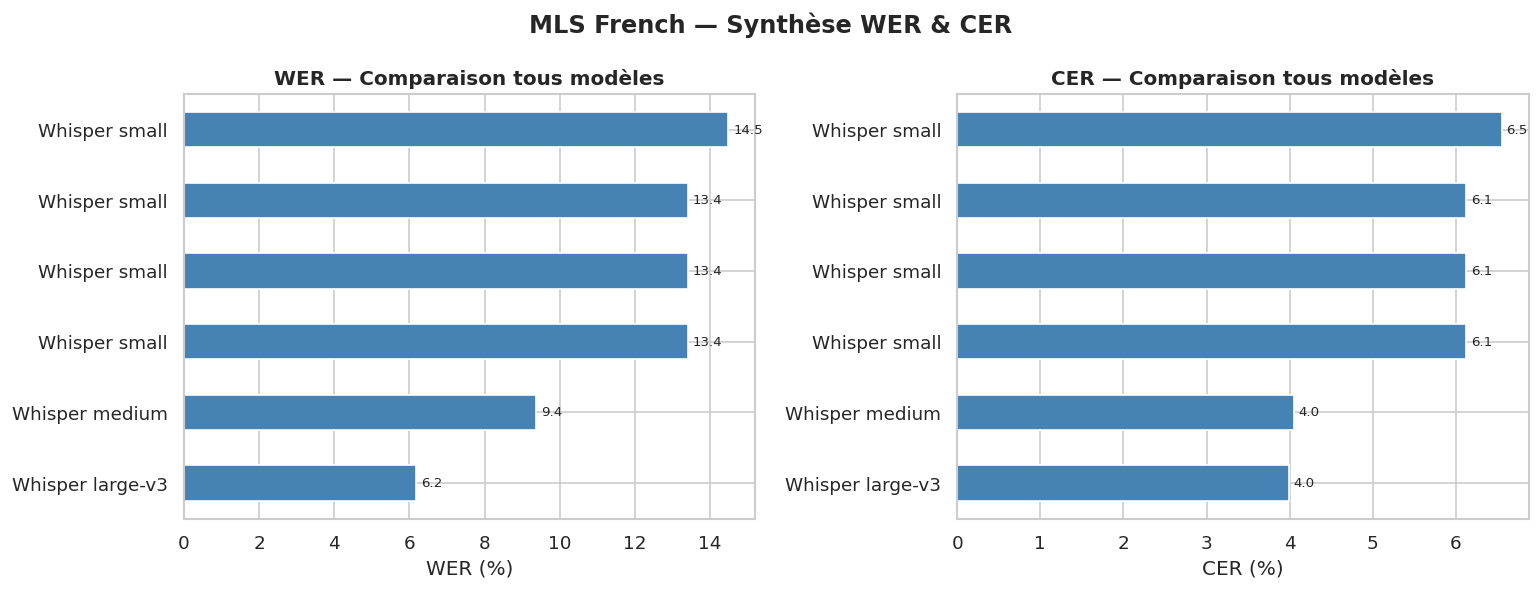

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ["WER (%)", "CER (%)"]):
    df_synth.set_index("Modèle")[metric].sort_values().plot(
        kind="barh", ax=ax, color="steelblue", edgecolor="white"
    )
    ax.set_title(f"{metric[:3]} — Comparaison tous modèles", fontweight="bold")
    ax.set_xlabel(metric); ax.set_ylabel("")
    for c in ax.containers:
        ax.bar_label(c, fmt='%.1f', padding=3, fontsize=8)
plt.suptitle("MLS French — Synthèse WER & CER", fontweight="bold")
plt.tight_layout()
save_fig("fig_synthesis.png"); plt.show()

In [33]:
# ── Upload final de toutes les figures sur WandB ──────────────────────────────
run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY,
                 name="figures-final", reinit="finish_previous")
figs = glob.glob(f"{FIG_DIR}/fig_*.png")
art  = wandb.Artifact(_art_name("figures"), type="figures")
for f in figs:
    art.add_file(f)
    run.log({Path(f).stem: wandb.Image(f)})
run.log_artifact(art)
wandb.finish()

print("\n✅ Expériences terminées.")
print(f"   {len(figs)} figures uploadées sur WandB")
print(f"   CSV de synthèse : {LOCAL_CKPT_DIR}/synthesis_results.csv")
print("   Données prêtes pour le rapport IJCAI et les diapositives.")


✅ Expériences terminées.
   6 figures uploadées sur WandB
   CSV de synthèse : /content/drive/MyDrive/INF8225/checkpoints/synthesis_results.csv
   Données prêtes pour le rapport IJCAI et les diapositives.
